In [1]:
# Python Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from getdist import plots, MCSamples
from astropy.wcs import WCS
%matplotlib inline

In [2]:
# Img blocks Paths
imgblocks_paths = "./imgblocks/"

## Def Functions

### Function to plot histograms and confidence curves

In [3]:
def chain_analysis(chains_path, latexN):
    """
    chains_path: same as imageblocks_name but of chain file name
    histogramsN: list that contain that free parameters of mcmc fit
    latexN: same as histogramsN but in latex format
    """
    # reading the chain
    chain = pd.read_csv(str(chains_path)+"bayes.dat",
                    comment='#',
                    sep="\s+",
                    index_col=False,
                    header=None)
    # histogram plot
    plt.figure(figsize=(15, 2))
    for ii in range(2,len(latexN)-1):
        plt.subplot(1,len(latexN),ii+1)
        plt.hist(chain[ii], density = True, ec = "black"); #burning initial steps
        plt.xlabel(str(latexN[ii]))
        plt.rcParams.update({"font.size": 15})
        plt.tight_layout()
    print("χ² value: ", np.mean(chain[len(chain.T)-1]))
    # preparing the chain sample using getdist library
    chain_plot = chain.loc[:, chain.columns != 0] # delete first column (sample)
    chain_plot = chain_plot.loc[:, chain_plot.columns != 1] # delete second column (ln)
    chain_plot = chain_plot.loc[:, chain_plot.columns != len(latexN)-1] # delete last column (chi2)
    sample = MCSamples(samples=np.array(chain_plot), names = latexN[2:-1], labels = latexN[2:-1])
    # plot the confidence curves
    g = plots.get_subplot_plotter()
    g.settings.line_labels =False
    g.triangle_plot([sample, sample], filled=True, line_args=[{'lw':1, 'color':'C3'}, {'lw':2, 'color':'slateblue'}],
              contour_colors=['C3','slateblue'], title_limit=1) # title limit is the level of marginalized probabily. 1 is equal to 67%, 2 is equal to 95% and soo on

### Function to plot the predicted images

In [4]:
def image_prediction(img_path, img_dataframe, chains_path):
    """
    img_path: path of imgblocks file
    img_dataframe: pandas dataframe containing the data in multifile file the format is:
    RA         |      Dec
    24.163145       0.138442
      ...              ...
    """
    # reading imgblock file (original images) and preparing the sky projection in WCS coordinates
    imgblock = fits.open(imgblocks_paths + str(img_path))
    wcs_helix = WCS(imgblock[1].header)
    
    # reading the predicted images
    images = pd.read_csv(chains_path+"image.dat",
                    comment='#',
                    usecols = [1,2],
                    names=["RA", "DEC"],
                    sep=" ",
                    index_col=False)
    # plot the images
    fig = plt.figure(figsize=plt.figaspect(0.2), frameon=True)
    for ii in range(1,4):
        ax = fig.add_subplot(1, 3, ii, projection=wcs_helix)
        ax.imshow(imgblock[ii].data, cmap='cividis', aspect='equal')
        plt.xlabel(r'RA')
        plt.ylabel(r'Dec')
        if ii==3: # if its the third picture plot the predicted images
            for jj in range(0,len(img_dataframe)):
                if jj==0:
                    ax.plot(img_dataframe["RA"][jj], img_dataframe["DEC"][jj], 'ko', transform=ax.get_transform('icrs'), zorder=10) # if it's the first dot, is the origen plot in a black dot ko
                else:
                    ax.plot(img_dataframe["RA"][jj], img_dataframe["DEC"][jj], 'w*', transform=ax.get_transform('icrs'), zorder=5) # the others are the proposed images and then plot in white
            for kk in range(0, len(images)):
                ax.plot(images["RA"][kk], images["DEC"][kk], 'r*', transform=ax.get_transform('icrs'), zorder=1) # loop under the predicted images and plot in red

### Confidence plot

In [5]:
results_path = "./LOG/results/"

In [6]:
my_results = pd.read_csv(str(results_path)+"myresults.txt",
                    comment='#',
                    sep="\s+",
                    index_col=False,
                    names=["e", "e_err1", "e_err2", "theta", "theta_err1", "theta_err2", "sigma", "sigma_err1", "sigma_err2", "sys"])
my_results.head()

,e,e_err1,e_err2,theta,theta_err1,theta_err2,sigma,sigma_err1,sigma_err2,sys
0,0.239,0.045,0.061,-2.0,1.6,1.6,434.320,0.300,0.300,1.1
1,0.210,0.026,0.034,0.5,1.4,1.4,434.310,0.300,0.300,1.2
2,1.470,0.530,0.390,161.5,1.8,1.8,498.000,15.000,18.000,2.0
3,1.230,0.150,0.170,54.0,2.8,2.8,547.293,0.012,0.012,3.1
4,0.365,0.078,0.170,53.8,2.4,2.4,479.500,9.300,9.300,3.2


In [7]:
anna_results = pd.read_csv(str(results_path)+"anna_results.txt",
                    comment='#',
                    sep="\s+",
                    index_col=False,
                    names=["e", "e_err", "theta", "theta_err","sigma", "sigma_err", "sys"])
anna_results.head()

,e,e_err,theta,theta_err,sigma,sigma_err,sys
0,0.11,0.008,9.28,1.30,440.58,1.40,1
1,0.08,0.120,4.90,24.95,434.59,2.96,1
2,0.32,0.060,6.41,1.27,442.03,3.26,1
3,0.51,0.000,164.10,0.00,524.00,0.00,2
4,0.51,0.000,164.00,0.00,525.00,8.90,2


In [8]:
params_dict={
    1:"e",
    2:"theta",
    3:"sigma"
}
colorcode={
    0:"lightcoral",
    1:"r",
    2:"darkred"
}
param_latex_dict = {
    1:"e",
    2:"θ",
    3:"σ"
}
def confidence_plot(sys):
    # plot the images
    fig = plt.figure(figsize=plt.figaspect(0.2), frameon=True)
    for ii in range(1,4):
        ax = fig.add_subplot(1, 3, ii)
        ax.errorbar(my_results[my_results["sys"]==sys][params_dict[ii]], 1, xerr=np.array([my_results[my_results["sys"]==sys][str(params_dict[ii])+"_err1"], my_results[my_results["sys"]==sys][str(params_dict[ii])+"_err2"]]), fmt='ko')
        
        sys_anna=sys
        if isinstance(sys, float) == True:
            sys_anna=str(sys)
            sys_anna=int(sys_anna[:-2])
            
        new_df = anna_results[anna_results["sys"]==sys_anna]
        new_df.reset_index(drop=True, inplace=True)
        for jj in range(0, len(new_df)):
            ax.errorbar(new_df[params_dict[ii]][jj], jj+2, xerr=np.array([[new_df[str(params_dict[ii])+"_err"][jj]], [new_df[str(params_dict[ii])+"_err"][jj]]]), fmt='o', c=str(colorcode[jj]))
        plt.xlabel(param_latex_dict[ii])
        plt.yticks([])

# CS82SL013639.16+000818.38

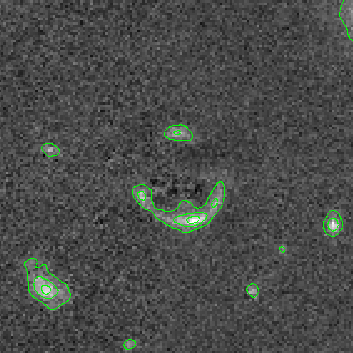

### Chain plot

χ² value:  3.13366008205897
Removed no burn in


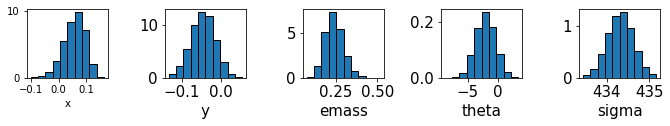

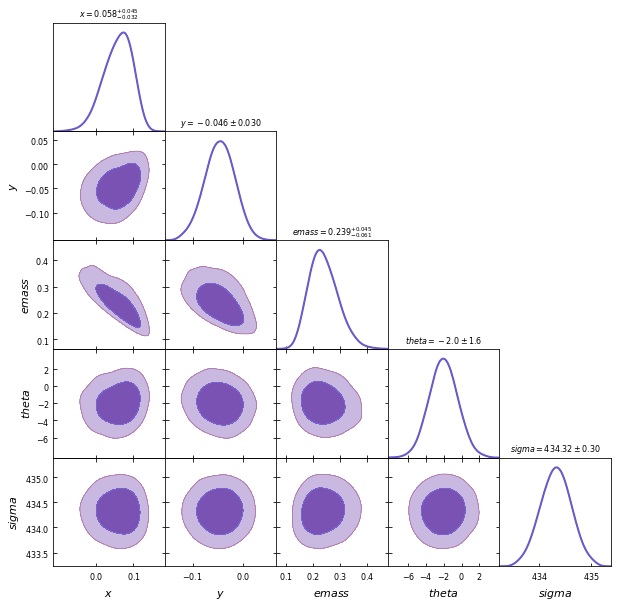

In [9]:
hist_latex_names = ["Nsample", "ln", "x", "y", "emass", "theta", "sigma", "chi2"]
chain_analysis("./LOG/sys_1/", hist_latex_names)

### Anna results for CS82SL013639.16+000818.38

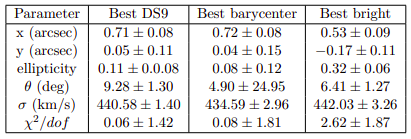

In [10]:
# proposed image positions
input_file = pd.DataFrame({"RA":[24.1631451, 24.1624011, 24.1628248, 24.1638961], "DEC":[0.1384420, 0.1379414, 0.1376109, 0.1381216]})

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


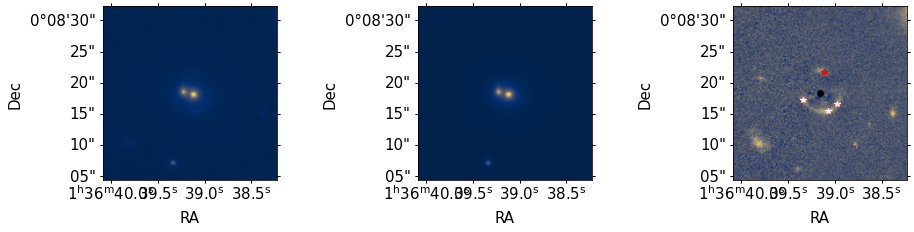

In [11]:
# call the plot function
image_prediction("imgblock1.fits", input_file, "./LOG/sys_1/")

## CS82SL013639.16+000818.38 with a counter image

χ² value:  8.3150322037981
Removed no burn in


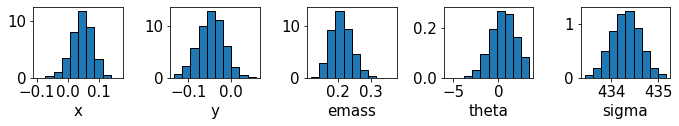

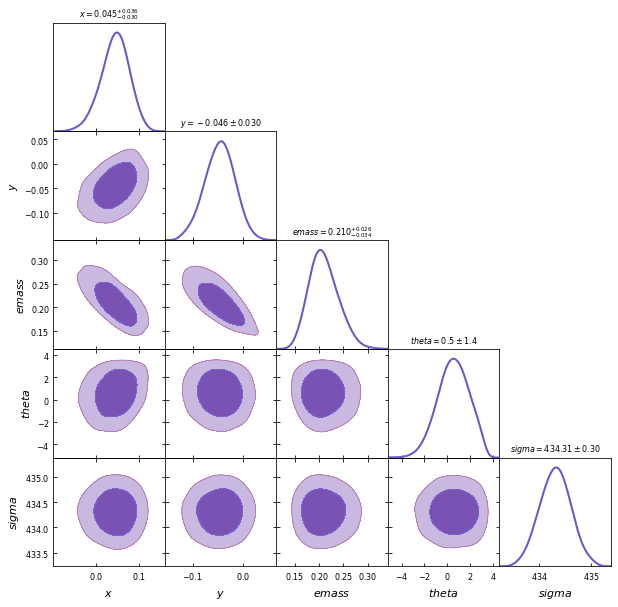

In [12]:
chain_analysis("./LOG/sys_1_ci/", hist_latex_names)

### comparison

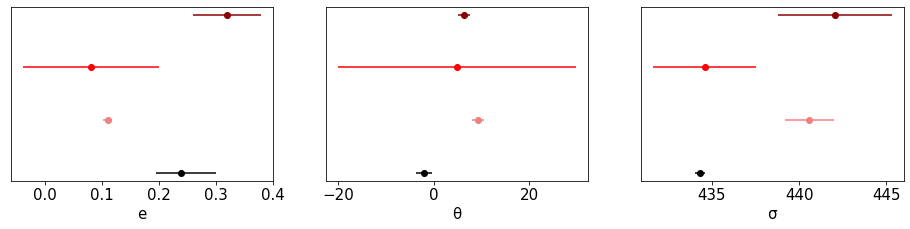

In [13]:
# no counter image
confidence_plot(1.1)

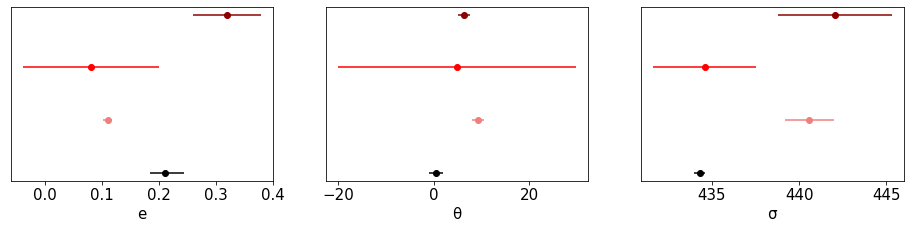

In [14]:
# with counter image
confidence_plot(1.2)

# CS82SL015824.81-003959.60

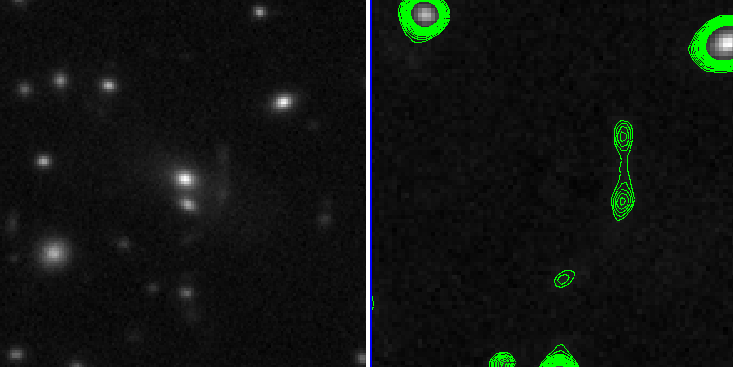

### Chain plot

χ² value:  3.9593795525237376
Removed no burn in


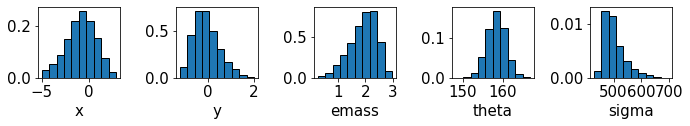

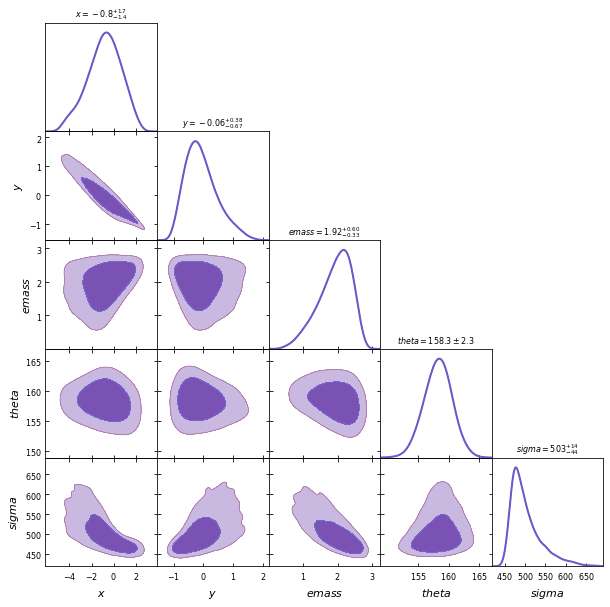

In [15]:
hist_latex_names = ["Nsample", "ln", "x", "y", "emass", "theta", "sigma", "chi2"]
chain_analysis("./LOG/sys_2/", hist_latex_names)

### Anna results for CS82SL015824.81-003959.60

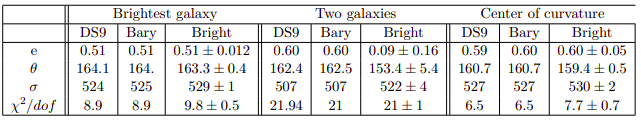

### comparison

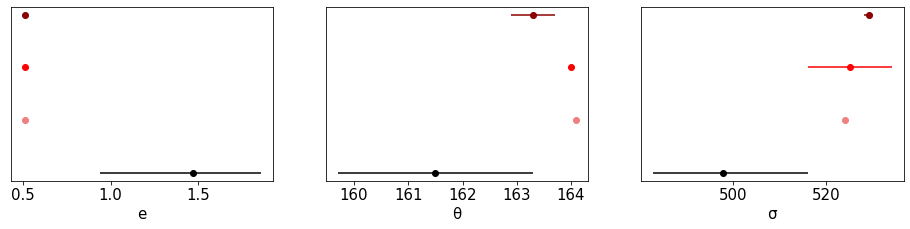

In [16]:
confidence_plot(2)

In [17]:
# proposed image positions
input_file = pd.DataFrame({"RA":[29.6033091, 29.6024870, 29.6024954, 29.6032048], "DEC":[-0.6664364, -0.6659979, -0.6667739, -0.6677084]})

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


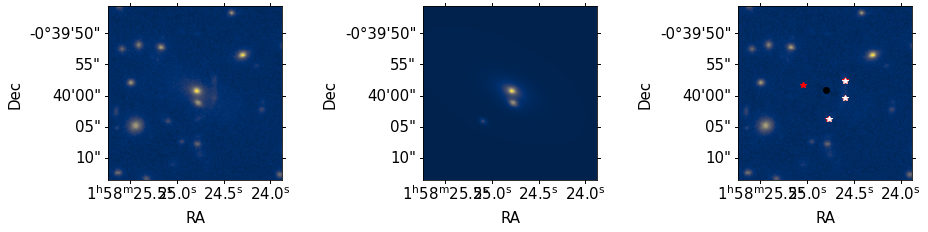

In [18]:
# call the plot function
image_prediction("imgblock2.fits", input_file, "./LOG/sys_2/")

### CS82SL015824.81-003959.60 with fixed positions

χ² value:  7.077644659570215
Removed no burn in


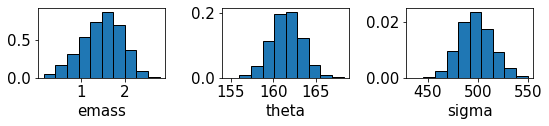

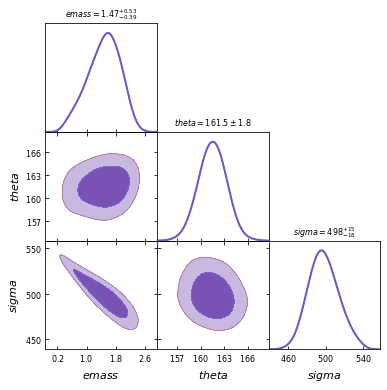

In [19]:
hist_latex_names = ["Nsample", "ln", "emass", "theta", "sigma", "chi2"]
chain_analysis("./LOG/sys_2_fixed_pos/", hist_latex_names)

### Anna results for CS82SL015824.81-003959.60

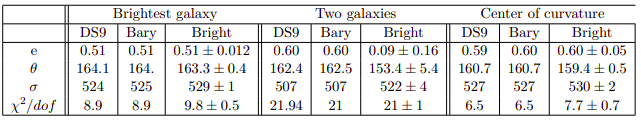

### comparison

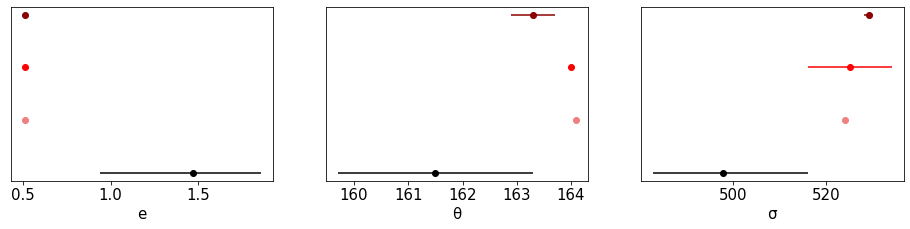

In [20]:
confidence_plot(2)

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


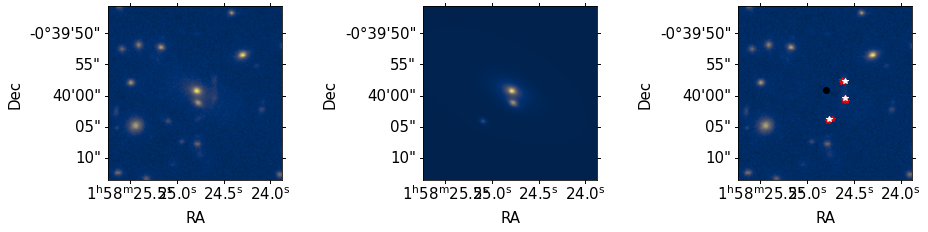

In [21]:
# call the plot function
image_prediction("imgblock2.fits", input_file, "./LOG/sys_2_fixed_pos/")

# CS82SL211527.25-003817.26

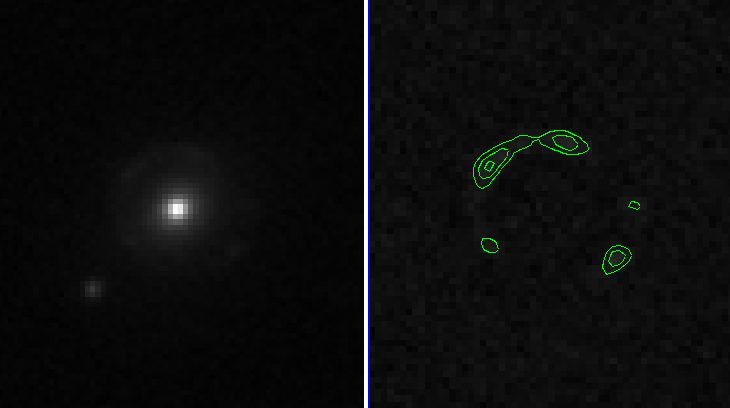

### Chain plot

χ² value:  2.5529866408795603
Removed no burn in


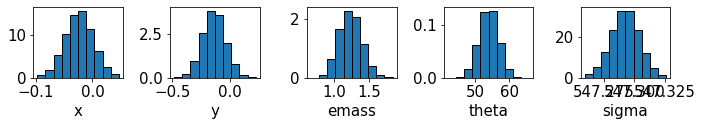

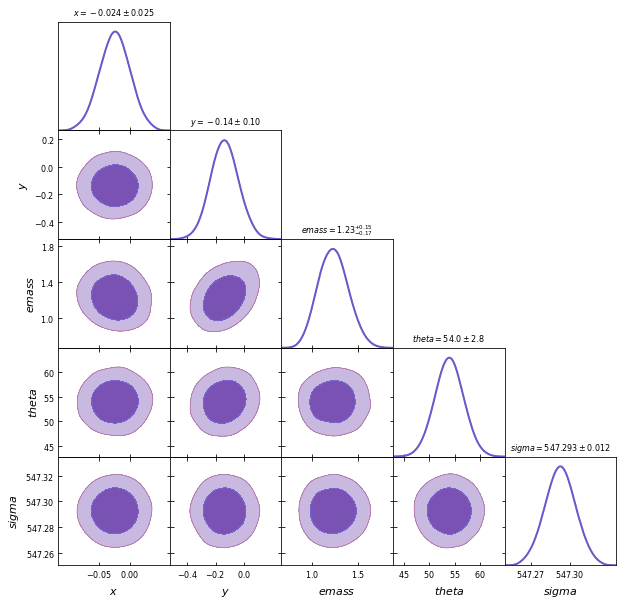

In [22]:
hist_latex_names = ["Nsample", "ln", "x", "y", "emass", "theta", "sigma", "chi2"]
chain_analysis("./LOG/sys_3/", hist_latex_names)

### Anna results for CS82SL211527.25-003817.26

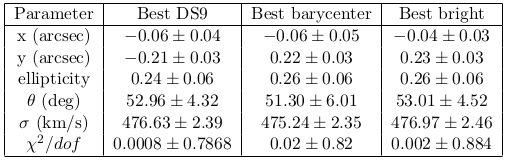

In [23]:
# proposed image positions
input_file = pd.DataFrame({"RA":[318.8635275, 318.8634023, 318.8640449, 318.8640365], "DEC":[-0.6380758, -0.6375417, -0.6377420, -0.6384096]})

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


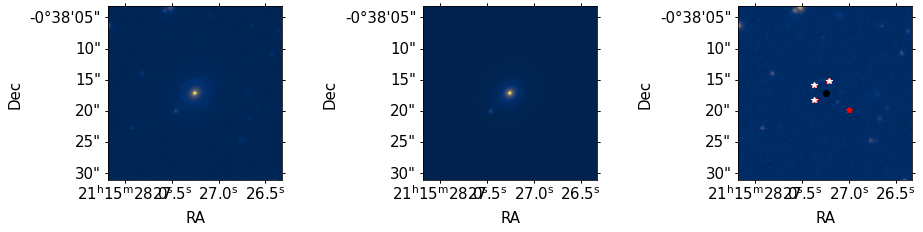

In [24]:
# call the plot function
image_prediction("imgblock3.fits", input_file, "./LOG/sys_3/")

## CS82SL211527.25-003817.26 with counter image

χ² value:  4.226012037531233
Removed no burn in


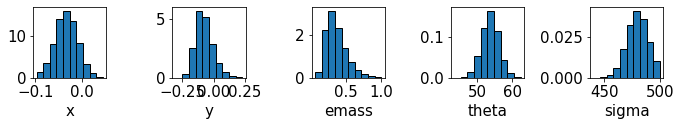

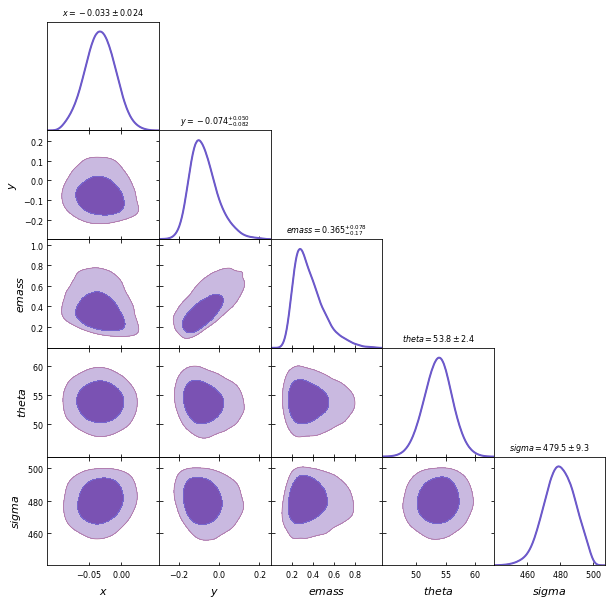

In [25]:
chain_analysis("./LOG/sys_3_ci/", hist_latex_names)

### comparison

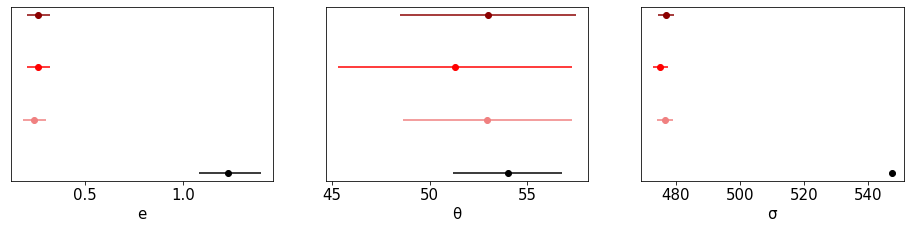

In [26]:
# no counter image
confidence_plot(3.1)

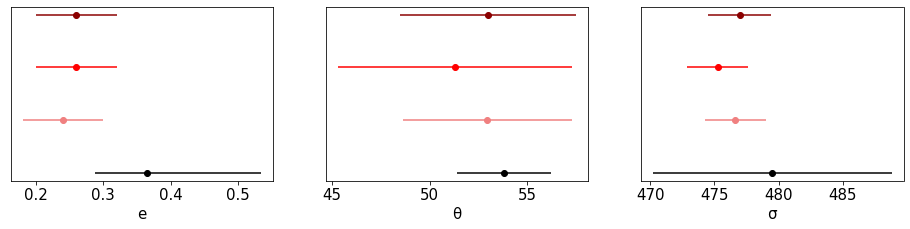

In [27]:
# with a counter image
confidence_plot(3.2)

# CS82SL230521.68-000211.52

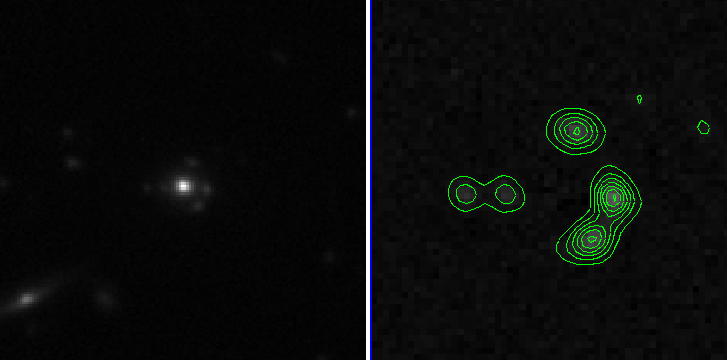

### Chain plot

χ² value:  2.987777323438281
Removed no burn in


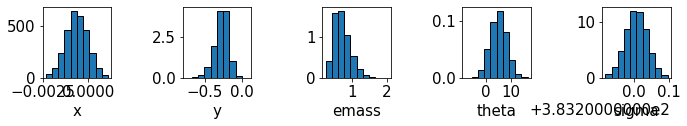

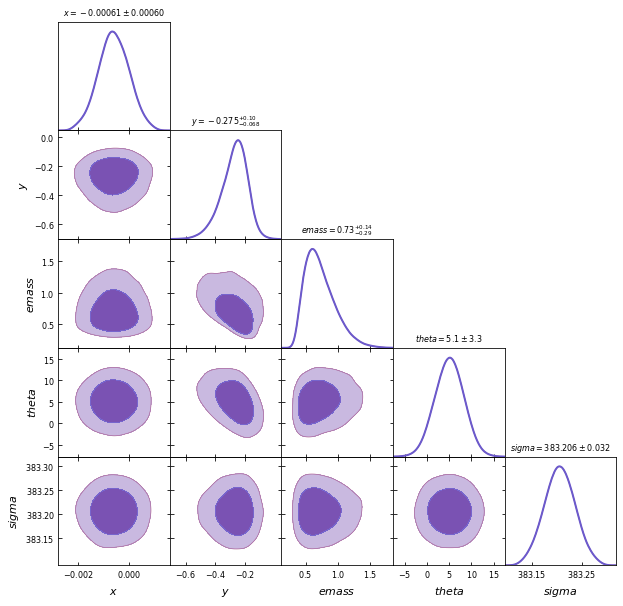

In [28]:
hist_latex_names = ["Nsample", "ln", "x", "y", "emass", "theta", "sigma", "chi2"]
chain_analysis("./LOG/sys_4/", hist_latex_names)

### Anna results for CS82SL230521.68-000211.52

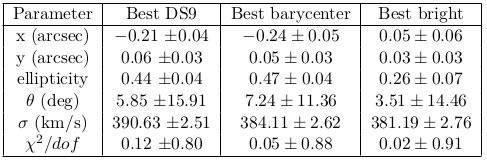

In [29]:
# proposed image positions
input_file = pd.DataFrame({"RA":[346.3403024, 346.3401022, 346.3398018, 346.3399854], "DEC":[-0.0364897, -0.0360558, -0.0366149, -0.0369486]})

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


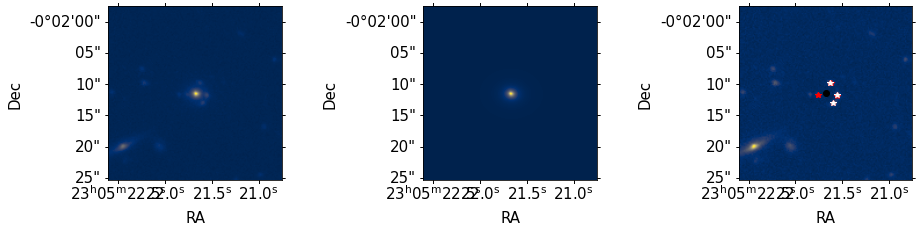

In [30]:
# call the plot function
image_prediction("imgblock4.fits", input_file, "./LOG/sys_4/")

## CS82SL230521.68-000211.52 with counter image

χ² value:  3.520328333033483
Removed no burn in


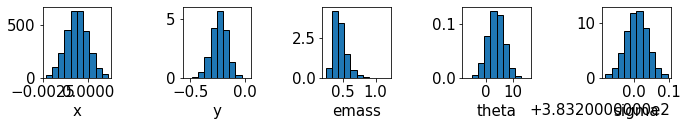

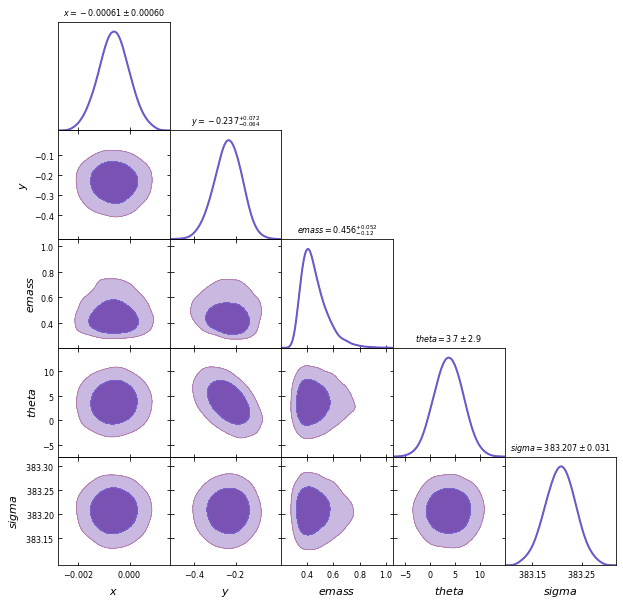

In [31]:
chain_analysis("./LOG/sys_4_ci/", hist_latex_names)

In [32]:
### Comparison

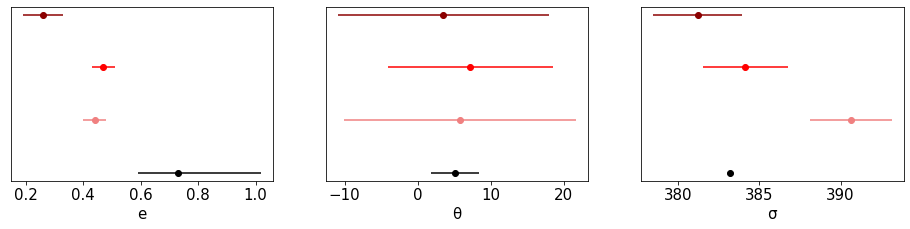

In [33]:
# no counter image
confidence_plot(4.1)

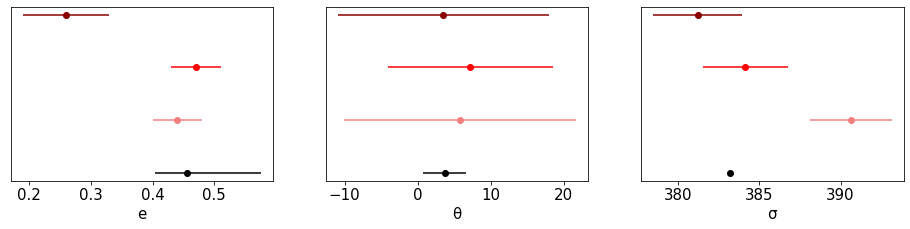

In [34]:
# with counter image
confidence_plot(4.2)